# Import Libraries

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings("ignore")
import os
os.makedirs("images",exist_ok=True)

# Load Data

In [143]:
df = pd.read_csv(r"C:\Users\sumit boyat\Downloads\netflix_titles.csv.zip")

# csv save
df.to_csv("Netflix_title.csv",index=False)

In [144]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Basic Exploration

In [145]:
df.shape



(8807, 12)

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [147]:
df["date_added"] = df["date_added"].str.strip()

In [148]:
df["date_added"] = pd.to_datetime(df["date_added"],errors="coerce")

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


# Create Month and Year columns

In [150]:
df["year_added"] = df["date_added"].dt.year

df["month_added"] = df["date_added"].dt.month_name()

In [151]:
df["year_added"] = df["year_added"].astype("Int64")

In [152]:
df[["date_added","year_added","month_added"]].head()

,date_added,year_added,month_added
0,2021-09-25,2021,September
1,2021-09-24,2021,September
2,2021-09-24,2021,September
3,2021-09-24,2021,September
4,2021-09-24,2021,September


In [153]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807,8797.0,8797
unique,8807,2,8807,4528,7692,748,NaN,NaN,17,220,514,8775,<NA>,12
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",<NA>,July
freq,1,6131,1,19,19,2818,NaN,NaN,3207,1793,362,4,<NA>,827
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-17 05:59:08.436967168,2014.180198,NaN,NaN,NaN,NaN,2018.871888,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,2008.0,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,NaN,2018.0,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-02 00:00:00,2017.000000,NaN,NaN,NaN,NaN,2019.0,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-19 00:00:00,2019.000000,NaN,NaN,NaN,NaN,2020.0,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN,2021.0,NaN


#  Missing Values

In [154]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
year_added        10
month_added       10
dtype: int64

# Missing % Check

In [155]:
pd.DataFrame({
    "Missing Values" : df.isnull().sum(),
    "Missing %" : round(df.isnull().sum()/len(df)*100,2)
}).sort_values("Missing %",ascending=False)

,Missing Values,Missing %
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
year_added,10,0.11
month_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00


# Duplicated Check

In [156]:
df.duplicated().sum()

np.int64(0)

# Movie vs TV Shows Distribution
This visualization compares the number of moies and TV Shows available on Netflix to understand the platform's content strategy.

In [157]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [158]:
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

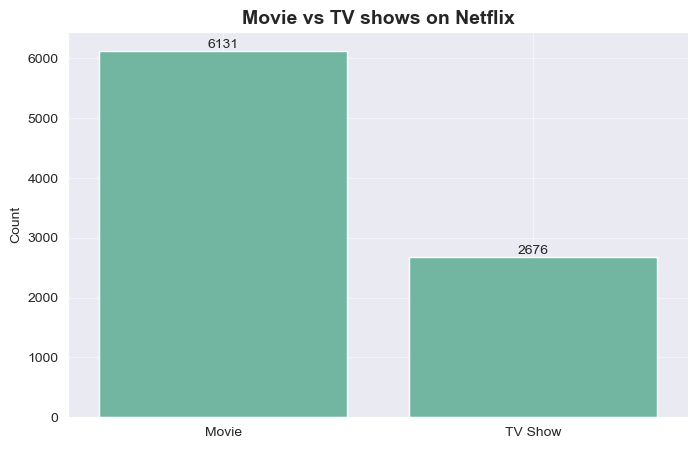

In [159]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="type"
)

for container in ax.containers:
    ax.bar_label(container)


plt.title("Movie vs TV shows on Netflix", 
          fontsize=14,
          weight="bold")
plt.xlabel("")
plt.ylabel("Count")
plt.grid(alpha=0.5)

plt.savefig("images/Movie_vs_TV.png",
            bbox_inches="tight",
            dpi=300)

plt.show()

### Business Insight
- Netflix has more Movies than TV Shows.
- This shows that Movies are a mojor part of Netflix's content library.
### Key Finding
- Movies make up the majority of content on Netflix.
- TV Shows represent a smaller but important part of the platform.


# top 10 Countries Producing Netflix Content

In [160]:
country_df = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_country = country_df.value_counts().head(10)
# top_country

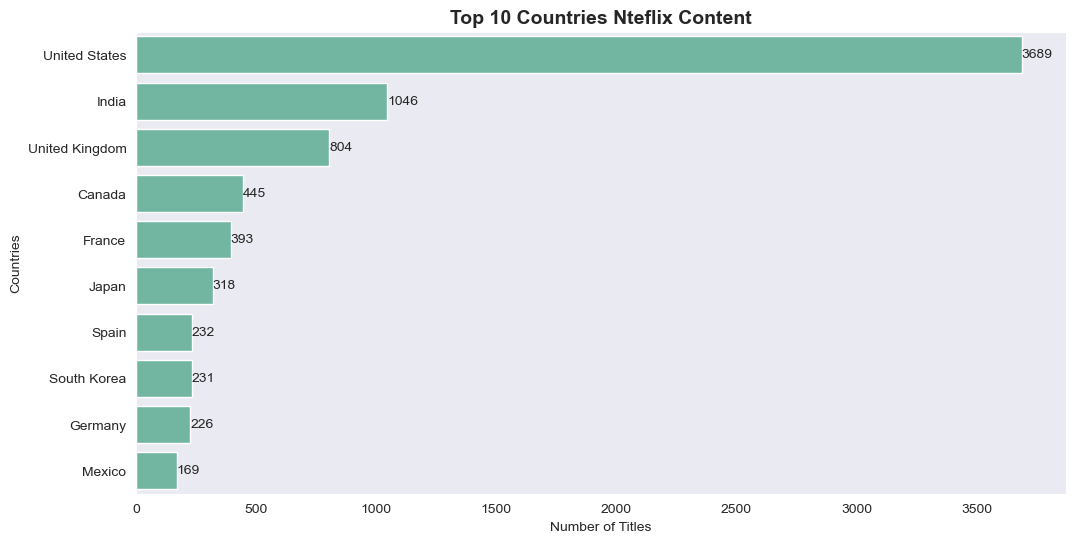

In [161]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_country.values,
    y=top_country.index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Countries Nteflix Content", 
          fontsize=14,
          weight="bold")

plt.xlabel("Number of Titles")
plt.ylabel("Countries")

plt.savefig("images/Top_10_Countries.png",
            bbox_inches="tight",
            dpi=300)

plt.show()

### Business Insight
- The Uinted States has the highest number of Netflix titles.
- India and UK are also important content producing countries.

### Key Finding
- The United States contributes the largest share of Netflix content.
- Most Netflix titles come from a small number of countries.

# Contect Growth by Year
This visualization shows how th enumber of titles addes to Netflix has changed over the years

In [162]:
year_content = (
    df["year_added"]
    .value_counts()
    .sort_index(ascending=False)
)
year_content

year_added
2021    1498
2020    1879
2019    2016
2018    1649
2017    1188
2016     429
2015      82
2014      24
2013      11
2012       3
2011      13
2010       1
2009       2
2008       2
Name: count, dtype: Int64

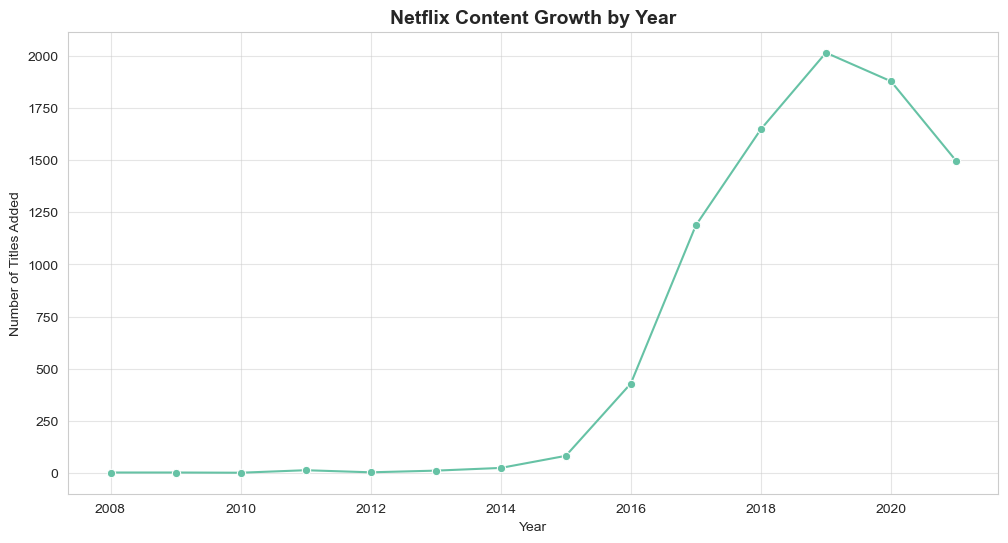

In [163]:
plt.figure(figsize=(12,6))

sns.set_style("whitegrid")
sns.set_palette("Set2")


ax = sns.lineplot(
    x=year_content.index,
    y=year_content.values,
    marker='o'
)
 
plt.title("Netflix Content Growth by Year",
          fontsize=14,
          weight="bold")

plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.grid(alpha=0.5)
plt.savefig("images/Content_Growth_by_year.png",
            bbox_inches="tight",
            dpi=300)

plt.show()

### Business Insight
- Netflix added more content every form 2015 to 2019.
- This shows that Netflix expanded its content library very quickly to attract more users around the world.
### Key Finding
- The highest number of titles were added in 2019.
- after 2019, the number of new titles started to decrease.

# Most Common Netflix Rating 
This visualization shows the distribution of content ratings avilable on Netflix .

In [164]:
rating_df = df['rating'].value_counts().head(10)
rating_df

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

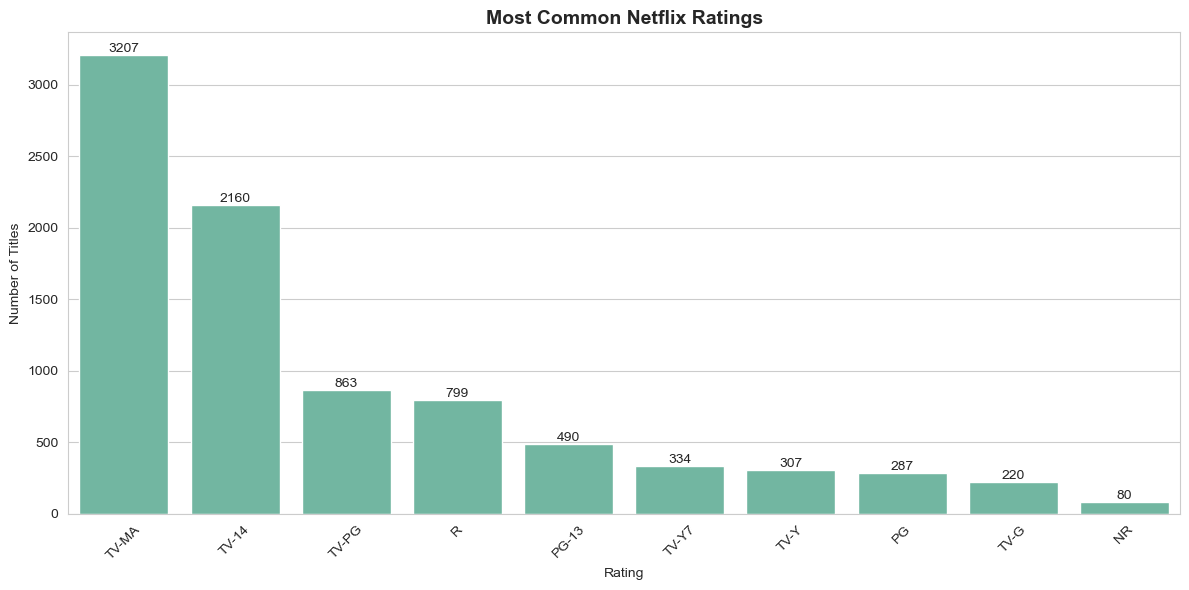

In [165]:
plt.figure(figsize=(12,6))

sns.set_style("whitegrid")
sns.set_palette("Set2")

ax = sns.barplot(
    x=rating_df.index,
    y=rating_df.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Most Common Netflix Ratings",fontsize=14,weight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.savefig("images/Most_Common_Ratings.png",bbox_inches="tight",dpi=300)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Business Insight
- Netflix offers the hightest number of titles under TV-MA and TV-14 ratings.
- This indicates that Netflix mainly targets adult and teenage audiences.
### Key Finding
- TV-MA is the most common rating on Netflix.
- Adult focused content repersents the largest share of the platform's library.

#  Top Genres🔥

In [166]:
genres_df = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

top_genres =genres_df.value_counts().head(10)
# top_genres

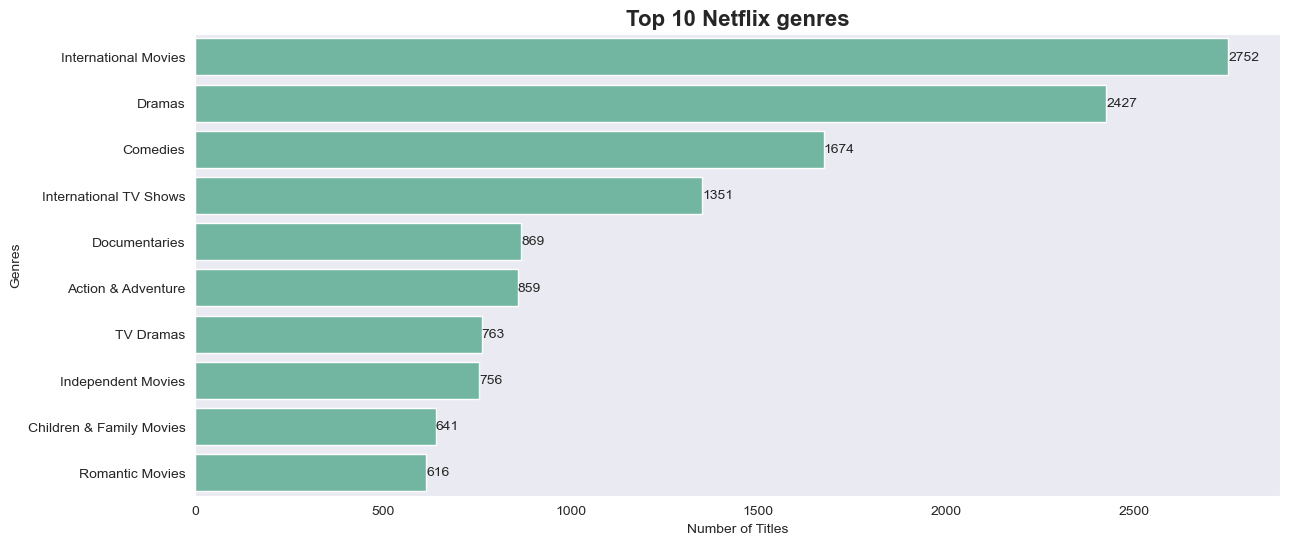

In [167]:
plt.figure(figsize=(14,6))

sns.set_style("dark")

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Netflix genres",
          fontsize=16,
          weight="bold")

plt.xlabel("Number of Titles")
plt.ylabel("Genres")

plt.savefig("images/Top_10_Netflix_Genres",
            bbox_inches="tight",
            dpi=300)

plt.show()

### Business Insight
- International Movies and Dramas are most common genres on Netflix.
- This shows that Netflix focuses on global audiences and story driven content.
### Key Finding
- International Movies is the most popular genres on Netflix.
- Drama content also plays a major role in the platform's library.
### Recruiter Analysis
- Netflix has a strong focus on international and drama based content.
- This strategy hepls attract viewes from diffrent countries and cultures.


# Top Directors 🎬

In [168]:
top_directors = (
    df["director"]
    .dropna()
    .value_counts()
    .head(10)
)

top_directors

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

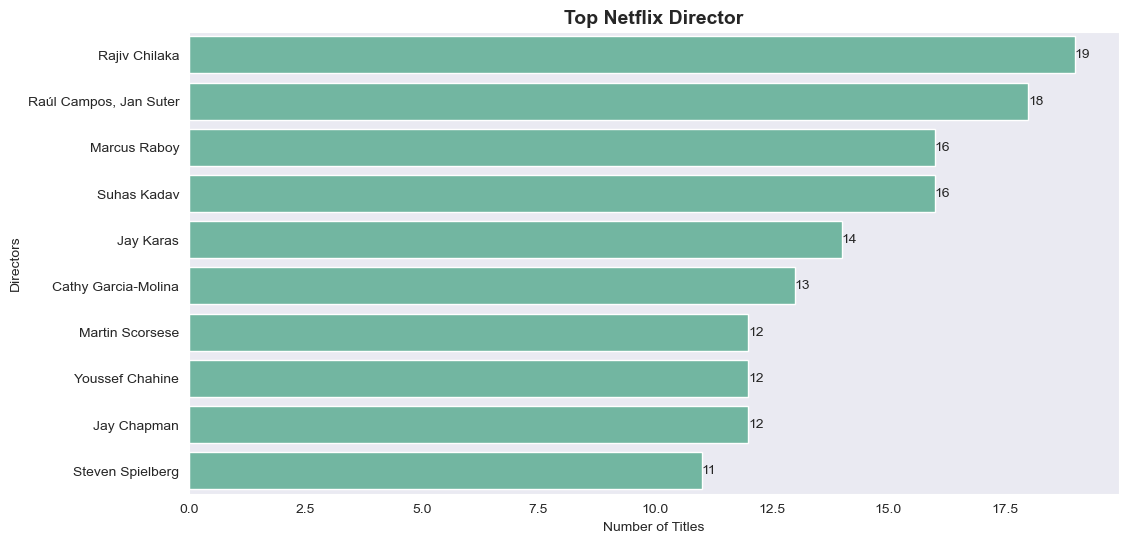

In [169]:
plt.figure(figsize=(12,6))

sns.set_style("dark")

ax = sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top Netflix Director",
          fontsize=14,
          weight="bold")

plt.xlabel("Number of Titles")
plt.ylabel("Directors")

plt.savefig("images/Top_Netflix_Directors.png",
            bbox_inches="tight",
            dpi=300)

plt.show()   



### Business Insight
- A small group of directors contributes a significant number of titles on Netflix.
- This indicates strong partnerships with recurring content creators.
### Key Finding
- Rajiv Chalaka is the most featured director on Netflix with 19 titles.
- Raul Campos and Jan Suter follow closely with 18 titles.

# Netflix Dashboard📊

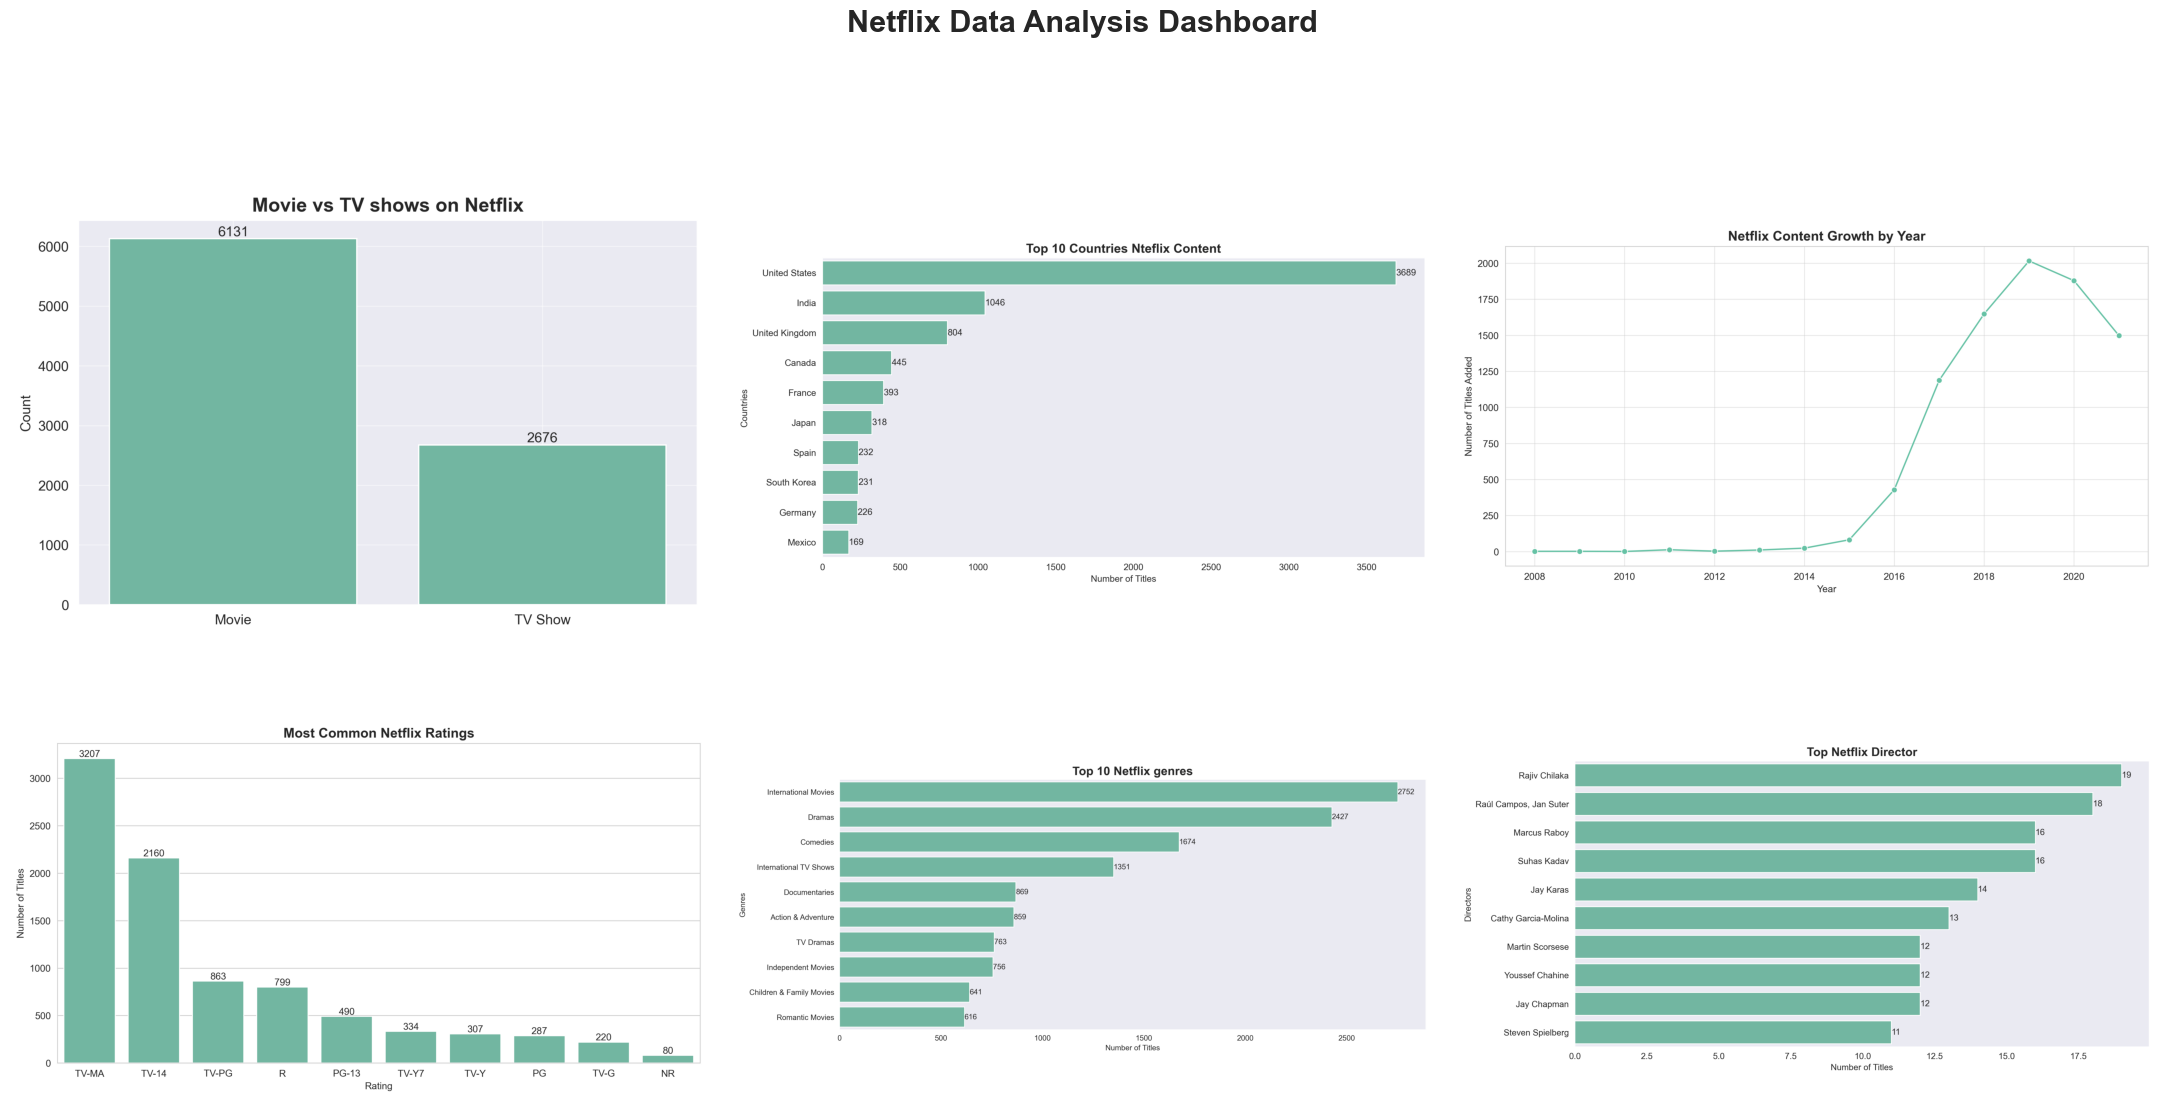

In [170]:
fig, axes = plt.subplots(2,3,figsize=(22,12))

charts = [
    "images/Movie_vs_TV.png",
    "images/Top_10_Countries.png",
    "images/Content_Growth_by_year.png",
    "images/Most_Common_Ratings.png",
    "images/Top_10_Netflix_Genres.png",
    "images/Top_Netflix_Directors.png"
]

for ax, chart in zip(axes.flatten(),charts):
    img = mpimg.imread(chart)
    ax.imshow(img)
    ax.axis("off")

    plt.suptitle("Netflix Data Analysis Dashboard",
                  fontsize=22, 
                  fontweight="bold",
                  y=1.02
)
    
plt.savefig("Netflix_Dashboard.png",
            bbox_inches="tight",
            dpi=300
            )
plt.tight_layout(pad=2)
plt.show()

# Final Analysis
- Movies are more popular than Shows on Netflix.
- USA has the highest number of Netflix titles,followed by India.
- Netflix content grew rapidly between 2016 and 2019.
- TV-MA and TV-14 are the most common ratings, showing a focus on    adult audiences.
- Drama and International Movies are the most popular genres.
- Netflix offers content form many directors, creating a diverse content library.
# Conclusion
Netflix has a large and diverse content collection.Movies dominate the platform and the USA is the leading content producer. The company continues to grow by offering popular genres and content for global audiences.